# Lab 24 — Source Coding: Huffman, Arithmetic Coding, LPC Speech, JPEG and Perceptual Audio

**Companion to Chapter 16** (*Source Coding: voice, audio, image, video*).
**Time needed:** about 90 minutes. **Difficulty:** core.

A modern radio link spends enormous effort to move bits reliably, and source coding decides how few bits are needed in the first
place. Two ideas do almost all the work. **Lossless coding** removes statistical redundancy and stops at the entropy. **Lossy coding**
throws away what the receiver will not miss: the fine structure of speech that a model can regenerate, the high spatial frequencies the
eye barely sees, the sounds the ear cannot hear under louder ones. This lab builds a small example of each, with the same code that drew
Chapter 16's figures: Huffman and canonical Huffman codes, a working adaptive arithmetic coder, an LPC vocoder that analyses a vowel and
resynthesises it at a new pitch, a baseline-JPEG-like image coder with a quality slider, and a psychoacoustic model that predicts how
much noise you can add to music before anyone notices.
Library code: `commlib/sourcecoding.py` (uses `commlib/infotheory.py` for Huffman).

### What you will learn
1. Build Huffman and canonical Huffman codes and measure them against the entropy of English letters.
2. Understand arithmetic coding as interval subdivision, and run a real adaptive context-model coder (orders 0–3).
3. Analyse speech with LPC (Levinson–Durbin): envelope, formants, prediction gain, line spectral frequencies; resynthesise it.
4. Code images with the 8×8 DCT, quantisation tables and run-length/Huffman coding; trade bits per pixel against PSNR.
5. Compute a masking threshold and shape quantisation noise beneath it.

### Prerequisites
Lab 19 (entropy, Huffman), Lab 16 (quantisation, PCM), Lab 17 (filters). Chapter 16.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Huffman and canonical Huffman codes for English | |
| 2 | Arithmetic coding: intervals and an adaptive coder | yes |
| 3 | LPC: the vocal tract as an all-pole filter | yes |
| 4 | A baseline JPEG coder | yes |
| 5 | Perceptual audio coding: masking and shaped noise | yes |

In [1]:
import os, sys, zlib, bz2, lzma, io
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import commlib as cl
from commlib import sourcecoding as sc
from commlib import infotheory as it
from commlib import labkit as lk

rng = lk.setup(seed=24, lab="24")

def play(x, fs, label=""):
    """An audio player in Jupyter; a note in the pre-built notebook."""
    if lk.is_static() or not lk._in_notebook():
        lk.note(f"Audio '{label}': run the notebook in Jupyter to listen ({len(x) / fs:.1f} s at {fs} Hz).")
        return
    from IPython.display import Audio, display
    print(label); display(Audio(np.asarray(x, float), rate=fs, normalize=True))

Lab 24 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 24


## 1. Huffman and canonical Huffman codes for English

For the 27 symbols of English (a–z and space) a Huffman code assigns each letter a length close to $-\log_2 p$: 3 bits for space and E,
up to 10 or more for Q, Z and J. Its average length lies between $H$ and $H+1$. A **canonical** Huffman code keeps the same lengths but
assigns codewords in a fixed order (by length, then symbol), so the decoder needs only the list of lengths: DEFLATE (ZIP, PNG), JPEG and
MP3 all transmit their tables this way. The text is Chapter 1 of the book, about 34 000 characters.

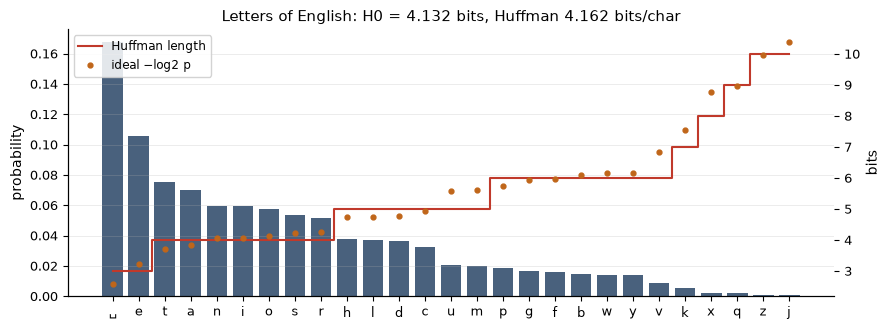

symbol,count,length,canonical codeword
␣,5655,3,000
e,3566,3,001
t,2552,4,1010
a,2361,4,0100
n,2018,4,0110
i,2017,4,0101
o,1946,4,0111
s,1806,4,1001
…,,,
x,77,8,11111110


,
entropy H0 (bits/char),4.132
Huffman average length,4.162
encoded size (bits),140434
decodes correctly,True
Kraft sum,1


In [3]:
text = sc.load_text()
N = len(text)
cnt = Counter(text)
syms = sorted(cnt, key=lambda s: -cnt[s])
p = np.array([cnt[s] for s in syms]) / N
lengths = it.huffman_lengths(cnt)
canon = sc.canonical_huffman(lengths)
H0 = it.entropy(p)
Lbar = sum(cnt[s] * lengths[s] for s in syms) / N
bits = sc.huffman_encode(text, canon)
ok = "".join(sc.huffman_decode(bits, canon)) == text
f, ax = lk.fig("wide")
xs = np.arange(len(syms))
ax.bar(xs, p, color=lk.NAVY, alpha=0.8)
ax.set_xticks(xs, ["␣" if s == " " else s for s in syms]); ax.set_ylabel("probability"); ax.grid(axis="x", visible=False)
b = ax.twinx(); b.step(xs, [lengths[s] for s in syms], where="mid", color=lk.RED, label="Huffman length")
b.plot(xs, -np.log2(p), "o", color=lk.ORANGE, ms=3.5, label="ideal −log2 p"); b.set_ylabel("bits"); b.grid(False); b.legend(loc="upper left")
ax.set_title(f"Letters of English: H0 = {H0:.3f} bits, Huffman {Lbar:.3f} bits/char")
lk.show(f)
lk.table([[("␣" if s == " " else s), cnt[s], lengths[s], canon[s]] for s in syms[:8]] + [["…", "", "", ""]] +
         [[s, cnt[s], lengths[s], canon[s]] for s in syms[-4:]], ["symbol", "count", "length", "canonical codeword"])
lk.table([["entropy H0 (bits/char)", H0], ["Huffman average length", Lbar], ["encoded size (bits)", len(bits)],
          ["decodes correctly", ok], ["Kraft sum", it.kraft_sum(lengths.values())]], ["", ""], fmt=".4g")

**What you should see.** $H_0 \approx 4.13$ bits and a Huffman average within about 0.03 bits of it: Huffman is excellent when no
probability is large. The lengths track $-\log_2 p$ to within one bit, the Kraft sum is exactly 1 (a complete code), and the canonical
code decodes the whole text.

### Try it yourself 1.1
Problem 16.1: probabilities 0.4, 0.2, 0.15, 0.1, 0.1, 0.05. What is the Huffman average length (bits)?

In [5]:
answer_1_1 = None
P6 = dict(zip("abcdef", [0.4, 0.2, 0.15, 0.1, 0.1, 0.05]))
lk.check("1.1 Huffman average length, Problem 16.1", answer_1_1,
         sum(P6[s] * L for s, L in it.huffman_lengths(P6).items()), atol=0.005)

[TODO] 1.1 Huffman average length, Problem 16.1: not attempted yet: replace the None with your answer

## 2. Arithmetic coding: intervals and an adaptive coder

Arithmetic coding maps a whole message to a sub-interval of [0, 1) whose width is the product of the symbol probabilities, then sends
the shortest binary fraction inside it: about $-\log_2(\text{width})$ bits, i.e. within 2 bits of the ideal for the entire message,
however skewed the probabilities. Chapter 16's example: $P(a,b,c) = (0.6, 0.3, 0.1)$, message "abac", width
$0.6\times0.3\times0.6\times0.1 = 0.0108$.

Because the probabilities can change at every symbol, arithmetic coding pairs naturally with **adaptive context models**: the
probability of the next letter given the previous $k$ letters, learned as the text is coded. `sc.ArithmeticCoder` is a real 32-bit
integer coder (Witten–Neal–Cleary): it produces a bit string and decodes it back.

"'abac' with P = (0.6, 0.3, 0.1)",
final interval,"[0.4572, 0.4680)"
width,0.0108
-log2(width),6.53 bits
codeword,"0.0111011 (binary) = 0.4609, 7 bits"


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

coder,real bits/char,ideal KT model (bits/char),decodes?
"arithmetic, order 0",4.138,4.137,True
"arithmetic, order 1",3.464,3.462,True
"arithmetic, order 2",3.009,3.075,(skipped)
"arithmetic, order 3",2.843,3.130,(skipped)
"Huffman, order 0",4.162,,
zlib -9 (LZ77 + Huffman),3.000,,
bzip2 (BWT),2.665,,
xz (LZMA),2.858,,


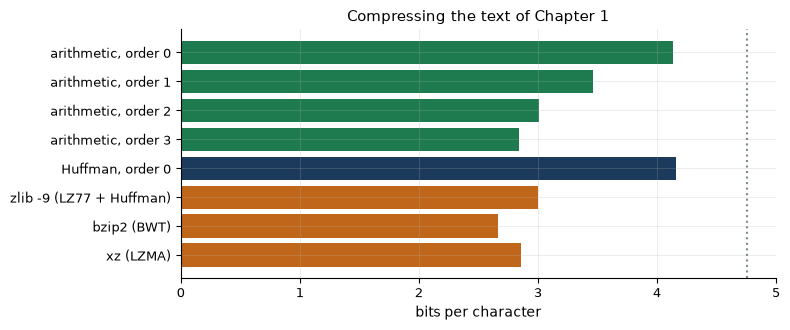

In [7]:
lo_, hi_, cw = sc.arith_interval("abac", {"a": 0.6, "b": 0.3, "c": 0.1})
lk.table([["final interval", f"[{lo_:.4f}, {hi_:.4f})"], ["width", f"{hi_ - lo_:.4f}"], ["-log2(width)", f"{-np.log2(hi_ - lo_):.2f} bits"],
          ["codeword", f"0.{cw} (binary) = {int(cw, 2) / 2 ** len(cw):.4f}, {len(cw)} bits"]], ["'abac' with P = (0.6, 0.3, 0.1)", ""])

def arith_demo(max_order=3, inc=16):
    rows = []
    for o in range(max_order + 1):
        ac = sc.ArithmeticCoder(order=o, inc=inc)
        bs = ac.encode(text)
        dec_ok = sc.ArithmeticCoder(order=o, alphabet=ac.alphabet, inc=inc).decode(bs, N) == text if o <= 1 else "(skipped)"
        rows.append([f"arithmetic, order {o}", len(bs) / N, sc.adaptive_ctx_bits(text, o) / N, dec_ok])
    raw = text.encode()
    for name, v in [("Huffman, order 0", Lbar), ("zlib -9 (LZ77 + Huffman)", 8 * len(zlib.compress(raw, 9)) / N),
                    ("bzip2 (BWT)", 8 * len(bz2.compress(raw, 9)) / N), ("xz (LZMA)", 8 * len(lzma.compress(raw, preset=9)) / N)]:
        rows.append([name, v, "", ""])
    lk.table(rows, ["coder", "real bits/char", "ideal KT model (bits/char)", "decodes?"], fmt={1: ".3f", 2: ".3f"})
    f, ax = lk.fig((8, 3.4))
    ax.barh(range(len(rows))[::-1], [r[1] for r in rows], color=[lk.GREEN] * (max_order + 1) + [lk.NAVY] + [lk.ORANGE] * 3)
    ax.set_yticks(range(len(rows))[::-1], [r[0] for r in rows]); ax.set_xlabel("bits per character"); ax.set_xlim(0, 5)
    ax.axvline(np.log2(27), color=lk.GRAY, ls=":"); ax.set_title("Compressing the text of Chapter 1")
    lk.show(f)

lk.interact(arith_demo, max_order=lk.islider(3, 0, 4, 1, "highest context order"), inc=lk.choice([1, 4, 16, 32], 16, "count increment"))

**What you should see.** The interval [0.4572, 0.4680) and a 7-bit codeword, the chapter's numbers. The real arithmetic coder matches the
ideal model at order 0 and 1 (and decodes perfectly); with a count increment of 16 it adapts faster than the "add-½" ideal and beats it at
orders 2–3, reaching about 2.8 bits/char, close to bzip2. Order-0 arithmetic coding gains almost nothing over Huffman here; its power is
in the context models it makes possible.

### Try it yourself 2.1
What is $-\log_2$ of the interval width for the message "aaaa" with $P(a) = 0.6$? (That is the ideal arithmetic-coded length.)

In [9]:
answer_2_1 = None
lk.check("2.1 ideal length of 'aaaa' (bits)", answer_2_1, -4 * np.log2(0.6), atol=0.01)

[TODO] 2.1 ideal length of 'aaaa' (bits): not attempted yet: replace the None with your answer

## 3. LPC: the vocal tract as an all-pole filter

Voiced speech is a periodic glottal excitation filtered by the vocal tract, whose resonances are the **formants**. Linear prediction fits
an all-pole model $1/A(z)$ to a 20–30 ms frame: the autocorrelation normal equations are solved by the Levinson–Durbin recursion, which
also yields the reflection coefficients and the prediction-error energy at every order. Chapter 16's hand example: $r = (1, 0.8, 0.5)$
gives $A(z) = 1 - 1.111z^{-1} + 0.389z^{-2}$ and a prediction gain of 5.1 dB. The test signal is a synthetic /a/ (formants 730, 1090,
2440, 3400 Hz) at $f_0 = 120$ Hz.

An **LPC vocoder** sends only $A(z)$, a gain, a voiced/unvoiced flag and the pitch for each frame (LPC-10 did it in 2.4 kb/s); the
receiver excites $1/A(z)$ with a pulse train or noise. Change the pitch and the same vocal tract "sings" a different note.

second-order worked example,
A(z) coefficients,[ 1. -1.111 0.389]
reflection coefficients,[-0.8 0.389]
prediction gain (dB),5.15


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

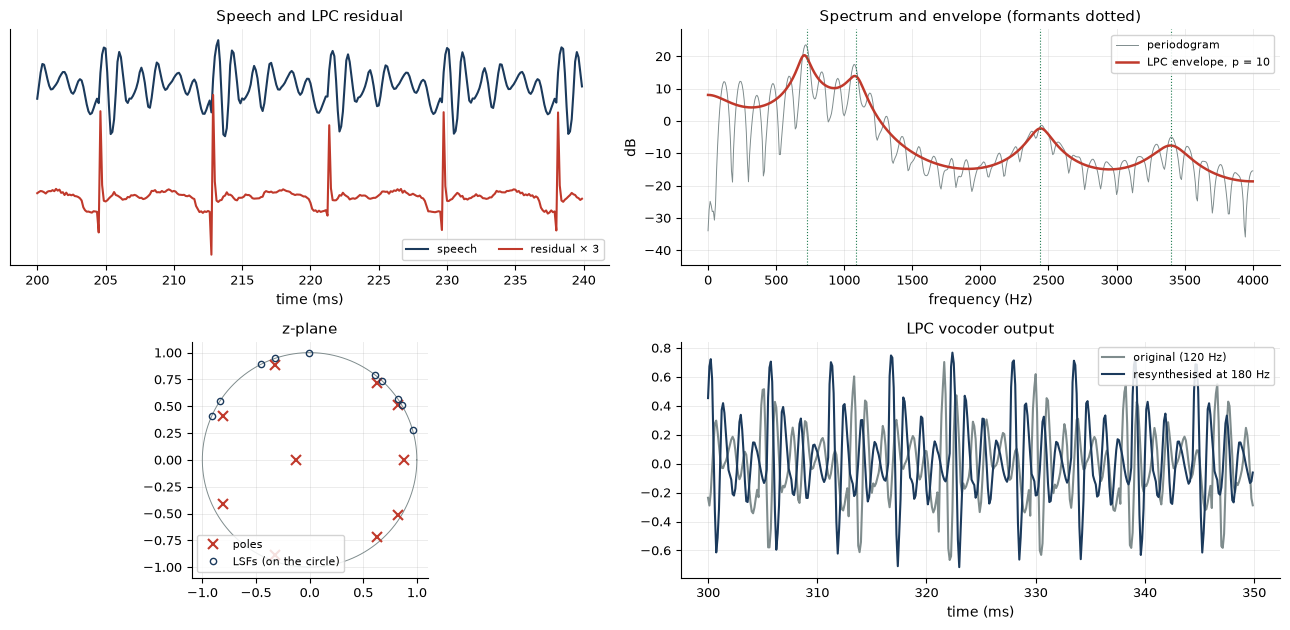

,
pole frequencies (Hz),[ 706 1089 2442 3402]
LSFs (Hz),[ 362 688 776 1055 1163 2009 2421 2600 3257 3462]
prediction gain (dB),12.0
bit rate if 10 LSFs x 3 bits + gain 5 + pitch 7 every 20 ms,2.1 kb/s


[info] Audio 'original vowel': run the notebook in Jupyter to listen (0.6 s at 8000 Hz).

[info] Audio 'LPC resynthesis': run the notebook in Jupyter to listen (0.6 s at 8000 Hz).

In [11]:
a2_, k2_, E2_ = sc.levinson(np.array([1.0, 0.8, 0.5]), 2)
lk.table([["A(z) coefficients", str(np.round(a2_, 3))], ["reflection coefficients", str(np.round(k2_, 3))],
          ["prediction gain (dB)", f"{10 * np.log10(E2_[0] / E2_[-1]):.2f}"]], ["second-order worked example", ""])
fs_v = 8000
vowel = sc.synth_vowel(dur=0.6, f0=120.0, fs=fs_v)

def lpc_demo(order=10, f0_new=180.0, whisper=False):
    fr = vowel[1600:1856]
    (a, ks, Es), xw = sc.lpc_frame(fr, order)
    nfft = 1024
    fq = np.arange(nfft // 2 + 1) * fs_v / nfft
    Pxx = np.abs(np.fft.rfft(xw, nfft)) ** 2
    _, Hh = signal.freqz([1], a, worN=fq, fs=fs_v)
    env = Es[-1] * np.abs(Hh) ** 2
    e = signal.lfilter(a, [1], vowel)
    y = sc.lpc_analysis_synthesis(vowel, fs_v, order, f0_new=None if whisper else f0_new)
    f, ax = lk.fig((13, 6.4), 2, 2)
    t = np.arange(len(vowel)) / fs_v * 1e3
    seg = slice(1600, 1920)
    ax[0, 0].plot(t[seg], vowel[seg], color=lk.NAVY, label="speech")
    ax[0, 0].plot(t[seg], 3 * e[seg] - 1.3, color=lk.RED, label="residual × 3")
    ax[0, 0].set_xlabel("time (ms)"); ax[0, 0].set_yticks([]); ax[0, 0].legend(fontsize=8, ncol=2); ax[0, 0].set_title("Speech and LPC residual")
    ax[0, 1].plot(fq, 10 * np.log10(Pxx + 1e-12), color=lk.GRAY, lw=0.7, label="periodogram")
    ax[0, 1].plot(fq, 10 * np.log10(env), color=lk.RED, lw=1.8, label=f"LPC envelope, p = {order}")
    for F, _ in sc.FORMANTS:
        ax[0, 1].axvline(F, color=lk.GREEN, ls=":", lw=0.8)
    ax[0, 1].set_ylim(10 * np.log10(env.max()) - 65, 10 * np.log10(env.max()) + 8)
    ax[0, 1].set_xlabel("frequency (Hz)"); ax[0, 1].set_ylabel("dB"); ax[0, 1].legend(fontsize=8); ax[0, 1].set_title("Spectrum and envelope (formants dotted)")
    poles = np.roots(a); lsf = sc.lpc_to_lsf(a)
    th = np.linspace(0, 2 * np.pi, 300)
    ax[1, 0].plot(np.cos(th), np.sin(th), color=lk.GRAY, lw=0.7)
    ax[1, 0].plot(poles.real, poles.imag, "x", color=lk.RED, ms=7, mew=1.5, label="poles")
    ax[1, 0].plot(np.cos(lsf), np.sin(lsf), "o", mfc="none", color=lk.NAVY, label="LSFs (on the circle)")
    ax[1, 0].set_aspect("equal"); ax[1, 0].legend(fontsize=8, loc="lower left"); ax[1, 0].set_title("z-plane")
    ts = np.arange(len(y)) / fs_v * 1e3
    ax[1, 1].plot(ts[2400:2800], vowel[2400:2800], color=lk.GRAY, label="original (120 Hz)")
    ax[1, 1].plot(ts[2400:2800], y[2400:2800], color=lk.NAVY, label="whispered" if whisper else f"resynthesised at {f0_new:.0f} Hz")
    ax[1, 1].set_xlabel("time (ms)"); ax[1, 1].legend(fontsize=8); ax[1, 1].set_title("LPC vocoder output")
    lk.show(f)
    pf = np.sort(np.angle(poles[poles.imag > 0])) * fs_v / (2 * np.pi)
    lk.table([["pole frequencies (Hz)", str(np.round(pf).astype(int))], ["LSFs (Hz)", str(np.round(lsf * fs_v / 2 / np.pi).astype(int))],
              ["prediction gain (dB)", f"{10 * np.log10(Es[0] / Es[-1]):.1f}"],
              ["bit rate if 10 LSFs x 3 bits + gain 5 + pitch 7 every 20 ms", f"{(10 * 3 + 5 + 7) / 0.02 / 1e3:.1f} kb/s"]], ["", ""])
    play(vowel, fs_v, "original vowel"); play(y, fs_v, "LPC resynthesis")

lk.interact(lpc_demo, order=lk.islider(10, 2, 20, 1, "LPC order p"), f0_new=lk.slider(180, 60, 400, 5, "new pitch (Hz)"),
            whisper=lk.choice([False, True], False, "noise excitation (whisper)"))

**What you should see.** With $p = 10$ the poles land near 706, 1089, 2443 and 3402 Hz (radii about 0.91–0.97): the formants, as the
chapter reports. The residual is nearly a pulse train at the pitch period, the part LPC cannot predict. Order 2 gives only one broad
resonance; beyond 10–12 the gain saturates for 8 kHz speech. The resynthesised waveform has the same envelope but the new pitch period.
The LSFs interlace on the unit circle: that ordering property is why every modern speech codec quantises LSFs.

### Try it yourself 3.1
Using `sc.levinson`, what is the third-order prediction-error energy $E_3$ for $r = (1, 0.8, 0.5, 0.2)$?

In [13]:
answer_3_1 = None
lk.check("3.1 E3 for r = (1, 0.8, 0.5, 0.2)", answer_3_1, sc.levinson(np.array([1, 0.8, 0.5, 0.2]), 3)[2][-1], atol=0.002)

[TODO] 3.1 E3 for r = (1, 0.8, 0.5, 0.2): not attempted yet: replace the None with your answer

## 4. A baseline JPEG coder

Baseline JPEG: level-shift, 8×8 DCT, divide by a quantisation table (scaled by the IJG quality factor), round; predict each block's DC from
the previous block; scan the AC coefficients in zigzag order into (run, size) symbols with an end-of-block marker; Huffman-code the symbols
and append the value bits. Our coder computes optimal Huffman tables for the image and does not count headers. Chapter 16: at Q = 50 the test
portrait costs about 0.90 bits per pixel.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

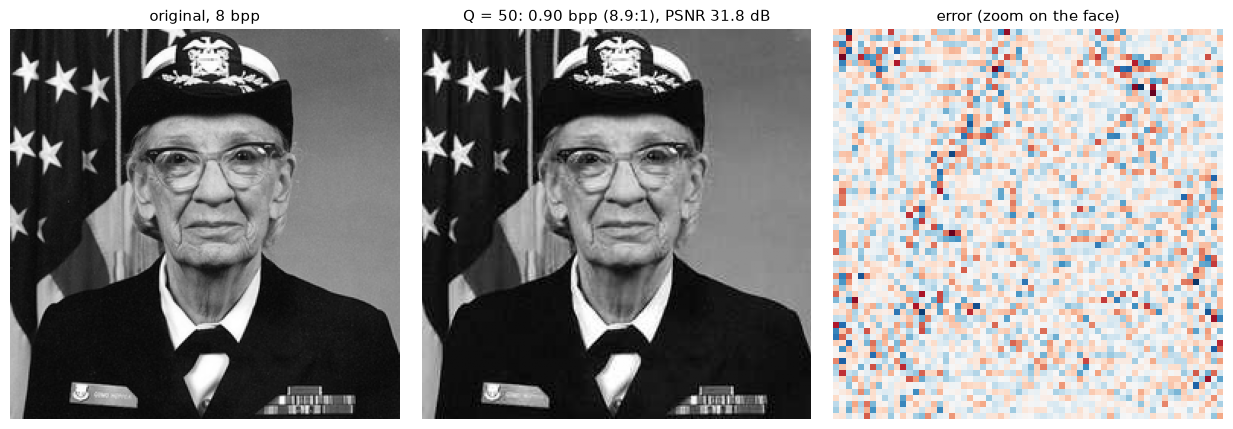

In [15]:
img = sc.load_image()

def jpeg_demo(quality=50, zoom=True):
    rec, bits = sc.toy_jpeg(img, quality)
    bpp = bits / img.size
    f, ax = lk.fig((12.5, 4.2), 1, 3)
    ax[0].imshow(img, cmap="gray", vmin=0, vmax=255); ax[0].set_title("original, 8 bpp")
    ax[1].imshow(rec, cmap="gray", vmin=0, vmax=255); ax[1].set_title(f"Q = {quality}: {bpp:.2f} bpp ({8 / bpp:.1f}:1), PSNR {sc.psnr(img, rec):.1f} dB")
    err = rec - img
    ax[2].imshow(err[96:160, 96:160] if zoom else err, cmap="RdBu", vmin=-30, vmax=30)
    ax[2].set_title("error (zoom on the face)" if zoom else "error")
    for a in ax:
        a.axis("off")
    lk.show(f)

lk.interact(jpeg_demo, quality=lk.islider(50, 1, 95, 1, "quality"), zoom=lk.choice([True, False], True, "zoom error"))

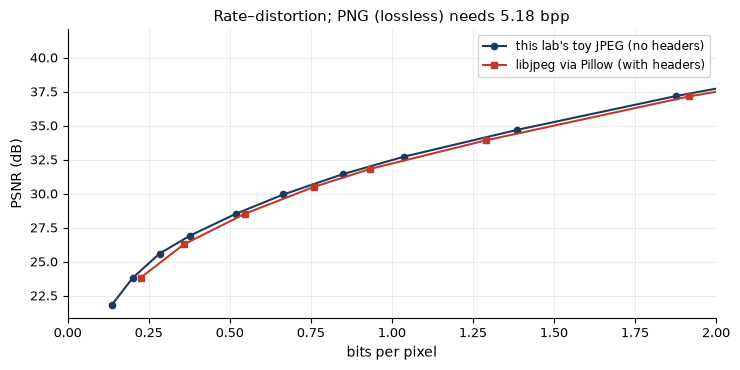

In [16]:
from PIL import Image
qs = [3, 5, 8, 12, 20, 30, 45, 60, 75, 85, 92]
toy = np.array([(lambda r: (r[1] / img.size, sc.psnr(img, r[0])))(sc.toy_jpeg(img, q)) for q in qs])
real = []
for q in [5, 10, 20, 35, 50, 70, 85, 93]:
    buf = io.BytesIO(); Image.fromarray(img.astype(np.uint8)).save(buf, "JPEG", quality=q, optimize=True)
    n_ = buf.tell(); buf.seek(0)
    dec = np.asarray(Image.open(buf).convert("L")).astype(float)
    real.append((8 * n_ / img.size, sc.psnr(img, dec)))
real = np.array(real)
buf = io.BytesIO(); Image.fromarray(img.astype(np.uint8)).save(buf, "PNG", optimize=True)
f, ax = lk.fig((7.5, 3.8))
ax.plot(toy[:, 0], toy[:, 1], "o-", color=lk.NAVY, label="this lab's toy JPEG (no headers)")
ax.plot(real[:, 0], real[:, 1], "s-", color=lk.RED, label="libjpeg via Pillow (with headers)")
ax.set_xlabel("bits per pixel"); ax.set_ylabel("PSNR (dB)"); ax.set_xlim(0, 2.0); ax.legend()
ax.set_title(f"Rate–distortion; PNG (lossless) needs {8 * buf.tell() / img.size:.2f} bpp")
lk.show(f)

**What you should see.** At Q = 50 about 0.90 bpp and 31.8 dB; at Q = 15 about 0.44 bpp, where blocks appear in smooth areas; at Q = 4 the
8×8 grid dominates. The error image shows ringing along edges (lost high frequencies) and blocking. The toy coder tracks libjpeg closely; the
remaining gap at low rates is the file header and the standard (not image-optimised) tables. Lossless PNG needs about five times the
bits of Q = 50 JPEG.

### Try it yourself 4.1
What quality factor gives the toy coder about 1.5 bits per pixel? (Search with `sc.toy_jpeg`; any $Q$ within ±5 of the answer passes.)

In [18]:
answer_4_1 = None
qq = np.arange(40, 96, 1)
bpps = np.array([sc.toy_jpeg(img, q)[1] / img.size for q in qq[::5]])
lk.check("4.1 quality for 1.5 bpp", answer_4_1, float(np.interp(1.5, bpps, qq[::5])), atol=5)

[TODO] 4.1 quality for 1.5 bpp: not attempted yet: replace the None with your answer

## 5. Perceptual audio coding: masking and shaped noise

A loud sound raises the threshold of hearing around it in frequency (simultaneous masking, spreading over a few critical bands) and in time.
MPEG-1's psychoacoustic model 1 estimates a **masking threshold** for each frame from tonal and noise maskers, the Schroeder spreading function
and the threshold in quiet; the coder then quantises each band just finely enough to keep the noise below it. Below: a synthetic music frame
(a harmonic tone plus a 6–9 kHz noise band, like Figure 16's psychoacoustic example), its threshold, and noise *shaped* to follow the
threshold at an adjustable offset. Listen in Jupyter: at 0 dB the model claims the noise is inaudible even though the SNR is modest; at
+10 dB it is clearly audible; white noise at the same SNR is obvious.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

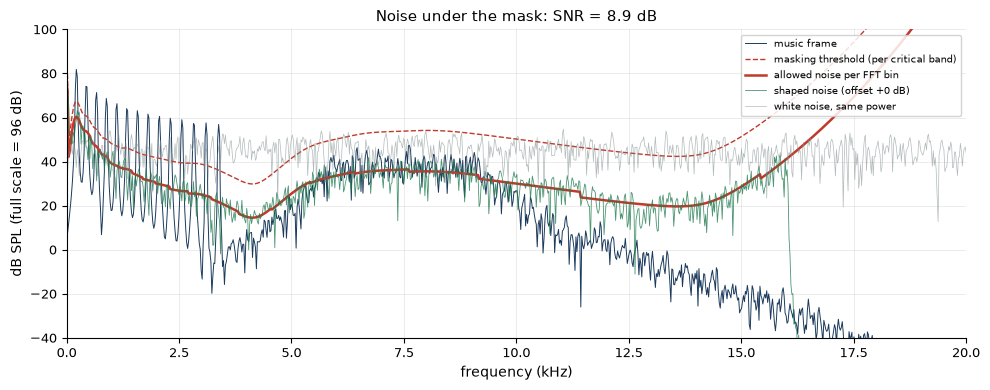

,
SNR of shaped noise (dB),8.88
fraction of bins (0.1-16 kHz) where shaped noise exceeds its allowance,0.44
fraction of bins where white noise of equal power exceeds it,0.93


[info] Audio 'music': run the notebook in Jupyter to listen (1.5 s at 44100 Hz).

[info] Audio 'music + shaped noise': run the notebook in Jupyter to listen (1.5 s at 44100 Hz).

[info] Audio 'music + white noise, same SNR': run the notebook in Jupyter to listen (1.5 s at 44100 Hz).

In [20]:
fs_a = 44100
n = np.arange(int(1.5 * fs_a))
music = sum(0.5 / h ** 1.1 * np.cos(2 * np.pi * 220 * h * (1 + 0.0005 * h * h) / fs_a * n + rng.uniform(0, 2 * np.pi)) for h in range(1, 15))
bb, aa = signal.butter(4, [6000, 9000], btype="band", fs=fs_a)
music = music + signal.lfilter(bb, aa, 0.08 * rng.standard_normal(len(n)))
music = 0.5 * music / np.max(np.abs(music))

def masking_demo(offset_db=0.0):
    y, nz = sc.shaped_noise(music, fs_a, offset_db, seed=1)
    snr = 10 * np.log10(np.mean(music ** 2) / np.mean(nz ** 2))
    white = rng.standard_normal(len(music)) * np.sqrt(np.mean(nz ** 2))
    fr = slice(30000, 32048)
    f, P, T = sc.masking_threshold(music[fr], fs_a)
    zb = np.floor(sc.bark(np.maximum(f, 1))).astype(int)
    allow = T - 10 * np.log10(np.bincount(zb)[zb])            # band threshold shared among the band's bins
    _, Pn, _ = sc.masking_threshold(nz[fr], fs_a)
    _, Pw, _ = sc.masking_threshold(white[fr], fs_a)
    fig, ax = lk.fig((10, 4.0))
    ax.plot(f / 1e3, P, color=lk.NAVY, lw=0.7, label="music frame")
    ax.plot(f / 1e3, T, color=lk.RED, lw=1.0, ls="--", label="masking threshold (per critical band)")
    ax.plot(f / 1e3, allow, color=lk.RED, lw=1.8, label="allowed noise per FFT bin")
    ax.plot(f / 1e3, Pn, color=lk.GREEN, lw=0.6, alpha=0.8, label=f"shaped noise (offset {offset_db:+.0f} dB)")
    ax.plot(f / 1e3, Pw, color=lk.GRAY, lw=0.5, alpha=0.6, label="white noise, same power")
    ax.set_xlim(0, 20); ax.set_ylim(-40, 100); ax.set_xlabel("frequency (kHz)"); ax.set_ylabel("dB SPL (full scale = 96 dB)")
    ax.legend(fontsize=7.5, loc="upper right"); ax.set_title(f"Noise under the mask: SNR = {snr:.1f} dB")
    lk.show(fig)
    band = (f > 100) & (f < 16000)
    lk.table([["SNR of shaped noise (dB)", snr],
              ["fraction of bins (0.1-16 kHz) where shaped noise exceeds its allowance", np.mean((Pn > allow)[band])],
              ["fraction of bins where white noise of equal power exceeds it", np.mean((Pw > allow)[band])]], ["", ""], fmt=".2f")
    play(music, fs_a, "music"); play(y, fs_a, "music + shaped noise"); play(music + white, fs_a, "music + white noise, same SNR")

lk.interact(masking_demo, offset_db=lk.slider(0, -20, 20, 1, "noise relative to threshold (dB)"))

**What you should see.** The masking threshold rises around the harmonics and the noise band and stays high above them (the spreading
function reaches several Bark upwards). Because the model's maskers are *band* powers, the threshold is a level per critical band; spread
over the FFT bins of each band it gives the solid "allowed noise per bin" curve, which the shaped noise follows (it is random and fitted
to the allowance in the median, so about half its bins sit slightly above). With the offset at 0 dB the SNR is only about 9 dB, yet the
model predicts the noise is essentially inaudible, while white noise of the same power exceeds the allowance in over 90% of the bins,
especially at high frequencies where the music has little energy. That is why a 128 kb/s MP3 or AAC can sound
transparent with a poor SNR. Real encoders keep a safety margin of several dB, and manage temporal masking and pre-echo, which this
frame-by-frame sketch ignores.

### Try it yourself 5.1
Using `sc.bark`, how many Bark (critical bands) separate 1 kHz from 2 kHz?

In [22]:
answer_5_1 = None
lk.check("5.1 Bark distance 1 kHz to 2 kHz", answer_5_1, float(sc.bark(2000) - sc.bark(1000)), atol=0.05)

[TODO] 5.1 Bark distance 1 kHz to 2 kHz: not attempted yet: replace the None with your answer

## Key takeaways
* Huffman is within a bit of $H$ per symbol and nearly perfect for English letters; canonical codes send only the lengths.
* Arithmetic coding separates modelling from coding: with adaptive context models it reaches ~2.8 bits/char on 34 kB of English.
* LPC models speech as excitation × all-pole vocal tract; LSFs are the robust parameters, and pitch can be changed freely.
* JPEG = DCT (energy compaction) + perceptual quantisation + zigzag run-length + Huffman; blocking and ringing are its signatures.
* Perceptual coders spend bits only above the masking threshold: they win on perceived quality, not SNR.

## Going further (hardware: USRP B200 / GNU Radio)
* Build a narrowband FM voice link (Lab 14) and a digital one: pass the synthetic vowel through `lpc_analysis_synthesis` at 2.4 kb/s, send the
  parameters over `gr02_psk_link.py`, and compare the bandwidth of the two links. Codec 2 (open source, 0.7–3.2 kb/s) is available as GNU
  Radio blocks (`gr-vocoder`).
* Receive a DAB+ or HD Radio broadcast with the B200 and an open-source decoder; both carry HE-AAC, the descendant of Section 5's ideas.

## Exercises
1. **(Warm-up)** Show that the canonical code of Section 1 has the same average length as the Huffman code it came from.
2. **(Core)** Add an order-2 *mixing* model to the arithmetic coder (average the order-0, 1 and 2 predictions with weights learned online) and
   compare with the best single order.
3. **(Core)** Replace the toy JPEG's 8×8 DCT with a 16×16 one (scale the quantisation table) and compare the R–D curves.
4. **(Stretch)** Implement a two-band MDCT coder for the music signal with bit allocation from `sc.masking_threshold`, and report the bit rate
   at which the noise stays below the threshold.

In [24]:
lk.summary()

[good] Lab 24 finished in 6.0 s. Self-checks: 0 passed, 0 failed, 5 still to do.